In [25]:
#Title: Flight Delay Analysis
#Author: Vishma Arachchi
#Date : 2024-02-03
#Purpose: This script is used to analyse the data in the csv file and find the best times and days of the week to minimise flight delays each year.




In [2]:
#IMPORTING PACKAGES AND LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [3]:
#IMPORTING DATASETS

df1 = pd.read_csv("/Users/vishmaarachchi/Documents/BSC/Programming coursework - PROJECT/2006.csv.bz2")


In [4]:
#DATA CLEANING AND FEATURE SELECTION

df1 = df1.drop(['ActualElapsedTime','DepTime','ArrTime','TaxiIn', 'TaxiOut','CancellationCode'], axis=1)

In [5]:
#Removing null values by imputation


#CRS_elapsed_time_mean
CRS_elapsed_time_mean = df1['CRSElapsedTime'].mean()
df1['CRSElapsedTime'] = df1['CRSElapsedTime'].fillna(CRS_elapsed_time_mean)

#Air_time_mean
Air_time_mean = df1['AirTime'].mean()
df1['AirTime'] = df1['AirTime'].fillna(Air_time_mean)


#Arrival_delay_mean.round(2)
Arrival_delay_mean = df1['ArrDelay'].mean()
df1['ArrDelay'] = df1['ArrDelay'].fillna(Arrival_delay_mean)

#Departure_delay_mean
Departure_delay_mean = df1['DepDelay'].mean()
df1['DepDelay'] = df1['DepDelay'].fillna(Departure_delay_mean)


In [6]:
#Checking for null values

df1.isnull().sum()
df1.isnull().sum()*100/df1.shape[0]

Year                 0.0
Month                0.0
DayofMonth           0.0
DayOfWeek            0.0
CRSDepTime           0.0
CRSArrTime           0.0
UniqueCarrier        0.0
FlightNum            0.0
TailNum              0.0
CRSElapsedTime       0.0
AirTime              0.0
ArrDelay             0.0
DepDelay             0.0
Origin               0.0
Dest                 0.0
Distance             0.0
Cancelled            0.0
Diverted             0.0
CarrierDelay         0.0
WeatherDelay         0.0
NASDelay             0.0
SecurityDelay        0.0
LateAircraftDelay    0.0
dtype: float64

In [7]:
#CHECKING CORRELATION BETWEEN ARRIVAL DELAY AND DEPARTURE DELAY(VERY HIGH CO-EFFITIENT)

correlation_coefficient = df1['ArrDelay'].corr(df1['DepDelay'])
print(correlation_coefficient)

0.915451502845212


In [8]:
#CREATING A NEW 'TOTAL DELAYS' COLUMN

df1['Total_delays']= df1['ArrDelay']+df1['DepDelay']
df1['Total_delays'] = df1['Total_delays'].round(3)


In [9]:
#SELECTING ENTRIES WHERE DELAYS HAVE OCCURED(i.e TOTAL_DELAYS>0)

df_only_delays = df1.loc[df1.Total_delays > 0]
df_only_delays.reset_index(drop=True, inplace=True)


In [10]:
df_only_delays['CRSDepTime'] = df_only_delays['CRSDepTime'].astype(str)


/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_8545/2884939316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_only_delays['CRSDepTime'] = df_only_delays['CRSDepTime'].astype(str)


In [11]:
#CALCULATING THE TIME OF THE DAY(HOUR OF DEPARTURE)

dff_1 = df_only_delays.iloc[:,[3,4,23,]]


In [12]:
hours = dff_1['CRSDepTime'].str[-4:-2]
dff_1['Hours'] = hours

/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_8545/1030726392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_1['Hours'] = hours


In [13]:
specified_string = '0'

dff_1['Hours'] = dff_1['Hours'].replace('',specified_string)

/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_8545/759533593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_1['Hours'] = dff_1['Hours'].replace('',specified_string)


In [14]:
dff_1['Hours'].unique()

array(['7', '8', '9', '18', '17', '20', '13', '15', '11', '5', '6', '16',
       '19', '10', '14', '12', '21', '22', '23', '1', '0', '2', '4', '3'],
      dtype=object)

In [15]:
dff_1

,DayOfWeek,CRSDepTime,Total_delays,Hours
0,3,745,4.000,7
1,3,820,25.000,8
2,3,945,4.000,9
3,3,1835,9.683,18
4,3,1725,18.776,17
...,...,...,...,...
3341527,5,1322,19.000,13
3341528,5,1940,10.000,19
3341529,5,1156,2.000,11
3341530,5,1155,92.000,11


In [16]:
#CONVERSION TO LONG AND THEN WIDE FORMAT


dff_1_long = pd.melt(dff_1, id_vars = ['Hours'],  value_vars = ['Total_delays'])
dff_1_wide = dff_1_long.pivot_table(values='value', index=['Hours'], columns=['variable'],aggfunc = np.mean)
dff_1_wide.reset_index(inplace=True)


In [17]:
#CONVERSION OF HOURS VARIABLE TO INT INORDER TO RANK

dff_1_wide['Hours'] = dff_1_wide['Hours'].astype(int)

In [18]:
sorted_df = dff_1_wide.sort_values(by='Hours')
sorted_df

variable,Hours,Total_delays
0,0,48.586941
1,1,43.095099
12,2,49.621644
17,3,100.916304
18,4,75.191686
19,5,36.496184
20,6,35.888213
21,7,36.996376
22,8,39.328080
23,9,40.570086


[Text(0, 0, '0am-1am'),
 Text(1, 0, '1am-2am'),
 Text(2, 0, '2am-3am'),
 Text(3, 0, '3am-4am'),
 Text(4, 0, '4am-5am'),
 Text(5, 0, '5am-6am'),
 Text(6, 0, '6am-7am'),
 Text(7, 0, '7am-8am'),
 Text(8, 0, '8am-9am'),
 Text(9, 0, '9am-10am'),
 Text(10, 0, '10am-11am'),
 Text(11, 0, '11am-12pm'),
 Text(12, 0, '12pm-1pm'),
 Text(13, 0, '1pm-2pm'),
 Text(14, 0, '2pm-3pm'),
 Text(15, 0, '3pm-4pm'),
 Text(16, 0, '4pm-5pm'),
 Text(17, 0, '5pm-6pm'),
 Text(18, 0, '6pm-7pm'),
 Text(19, 0, '7pm-8pm'),
 Text(20, 0, '8pm-9pm'),
 Text(21, 0, '9pm-10pm'),
 Text(22, 0, '10pm-11pm'),
 Text(23, 0, '11pm-12am')]

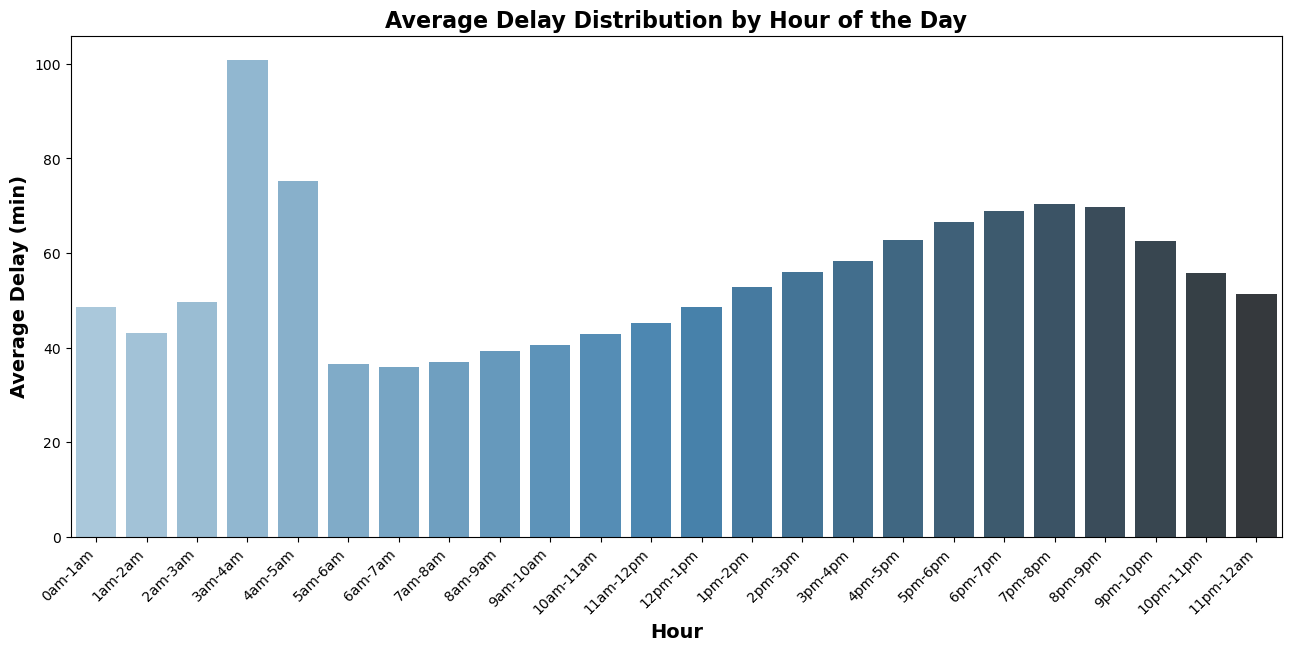

In [19]:
#PLOTTING THE GRAPH

barchart_labels = ["0am-1am",'1am-2am','2am-3am','3am-4am','4am-5am','5am-6am','6am-7am','7am-8am','8am-9am','9am-10am','10am-11am',
                   '11am-12pm','12pm-1pm','1pm-2pm','2pm-3pm','3pm-4pm','4pm-5pm','5pm-6pm','6pm-7pm','7pm-8pm',
                   '8pm-9pm','9pm-10pm','10pm-11pm','11pm-12am']


fig1, ax1 = plt.subplots(figsize=(12.8, 6.4), constrained_layout=True)
ax1 = sns.barplot(sorted_df, x="Hours", y="Total_delays", errorbar="sd",palette = 'Blues_d')
ax1.set_title("Average Delay Distribution by Hour of the Day", fontdict={"weight": "bold", "fontsize": 16})
ax1.set_xlabel("Hour", fontdict={"weight": "bold", "fontsize": 14})
ax1.set_ylabel("Average Delay (min)", fontdict={"weight": "bold", "fontsize": 14})
ax1.set_xticklabels(barchart_labels,rotation=45,ha='right') 

[Text(0, 0, 'Monday'),
 Text(1, 0, 'Tuesday'),
 Text(2, 0, 'Wednesday'),
 Text(3, 0, 'Thursday'),
 Text(4, 0, 'Friday'),
 Text(5, 0, 'Saturday'),
 Text(6, 0, 'Sunday')]

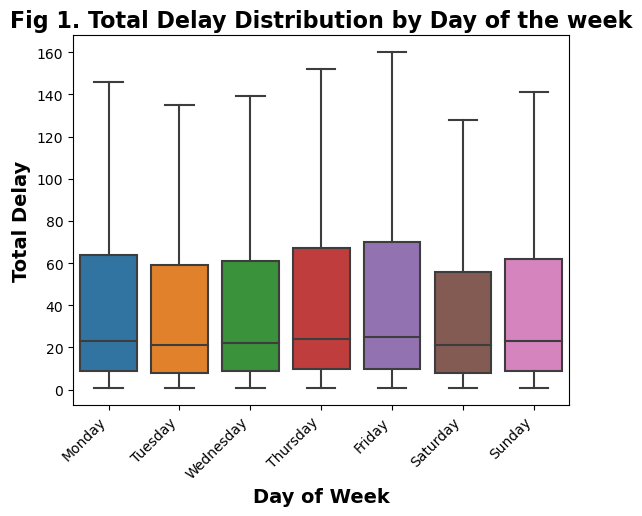

In [20]:
box_plot_labels =["Monday",'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots()

ax1 = sns.boxplot(x="DayOfWeek", y="Total_delays", order=np.sort(dff_1["DayOfWeek"].unique()), data=dff_1, showfliers = False )
ax1.set_title("Fig 1. Total Delay Distribution by Day of the week", fontdict={"weight": "bold", "fontsize": 16})
ax1.set_xlabel("Day of Week", fontdict={"weight": "bold", "fontsize": 14})
ax1.set_ylabel("Total Delay", fontdict={"weight": "bold", "fontsize": 14})
ax1.set_xticklabels(box_plot_labels,rotation=45,ha='right')